In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/sample_submission.csv
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/LICENSE
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/README.md
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/meta/esc50.csv
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/meta/esc50-human.xlsx
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/5-257349-A-15.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/5-195557-A-19.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/2-122820-B-36.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/1-115920-A-22.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/1-172649-C-40.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/

In [2]:
import subprocess
subprocess.run(["pip", "install", "--upgrade", "wandb", "-q"])
print("wandb upgraded")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.6/25.6 MB 78.4 MB/s eta 0:00:00
wandb upgraded


In [3]:
from kaggle_secrets import UserSecretsClient
import os
import wandb

user_secrets = UserSecretsClient()
wandb_api = user_secrets.get_secret("WANDB_API_KEY")
os.environ["WANDB_API_KEY"] = wandb_api
wandb.login()
print("WandB login successful.")
print("wandb version:", wandb.__version__)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: 24f2001946 (24f2001946-iitm) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


WandB login successful.
wandb version: 0.25.1


# Imports

In [4]:
# Import all required libraries
import os
import numpy as np
import pandas as pd
import librosa
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import random
import warnings
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, accuracy_score, classification_report
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
import wandb
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# Configuration and setup

In [5]:
BASE = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup"
GENRES = ["blues", "classical", "country", "disco", "hiphop", "jazz", "metal", "pop", "reggae", "rock"]
STEMS = ["bass.wav", "drums.wav", "other.wav", "vocals.wav"]
SR, N_MELS, HOP, DUR = 22050, 128, 512, 30
FIXED_LEN = int(SR * DUR / HOP) + 1
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_WORKERS = 4

WANDB_ENTITY = "24f2001946-iitm"
WANDB_PROJECT = "messy-mashup"

# Set random seeds for reproducibility
random.seed(67)
np.random.seed(67)
torch.manual_seed(67)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(67)

print('Device:', DEVICE)
print('Fixed mel length:', FIXED_LEN)

Device: cuda
Fixed mel length: 1292


# Dataset Path

In [6]:
# Find dataset path
def find_dataset_path():
    possible_paths = [
        BASE + "/genres_stems",
        "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems",
    ]
    for path in possible_paths:
        if os.path.exists(path):
            if any(g in os.listdir(path) for g in GENRES):
                print('Found dataset at:', path)
                return path
    for root, dirs, files in os.walk("/kaggle/input"):
        if any(g in dirs for g in GENRES):
            return root
    return None

DATASET_PATH = find_dataset_path()
if DATASET_PATH is None:
    raise ValueError("Cannot find dataset!")

Found dataset at: /kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems


# Train/Validation dataset splits

In [7]:
# Build train/validation dataset splits
def build_dataset(root, val_split=0.2, seed=67):
    tr = {g: {s[:-4]: [] for s in STEMS} for g in GENRES}
    va = {g: {s[:-4]: [] for s in STEMS} for g in GENRES}
    rng = random.Random(seed)
    print('Building dataset...')
    total_songs = 0
    
    for g in GENRES:
        genre_path = os.path.join(root, g)
        if not os.path.exists(genre_path):
            continue
            
        entries = sorted(os.listdir(genre_path))
        valid = []
        
        for entry in entries:
            entry_path = os.path.join(genre_path, entry)
            if not os.path.isdir(entry_path):
                continue
                
            files = {}
            complete = True
            for st in STEMS:
                fpath = os.path.join(entry_path, st)
                if os.path.exists(fpath) and os.path.getsize(fpath) >= 4096:
                    files[st] = fpath
                else:
                    complete = False
                    break
            if complete and len(files) == 4:
                valid.append(files)
                
        if len(valid) == 0:
            continue
            
        rng.shuffle(valid)
        n_val = max(1, int(len(valid) * val_split))
        n_train = len(valid) - n_val
        
        for song in valid[:n_train]:
            for k, v in song.items():
                tr[g][k[:-4]].append(v)
        for song in valid[n_train:]:
            for k, v in song.items():
                va[g][k[:-4]].append(v)
                
        total_songs += len(valid)
        print(' ', g, ':', n_train, 'train,', n_val, 'val')
        
    print('Total songs:', total_songs)
    return tr, va

tr, va = build_dataset(DATASET_PATH)

Building dataset...
  blues : 80 train, 20 val
  classical : 80 train, 20 val
  country : 80 train, 20 val
  disco : 80 train, 20 val
  hiphop : 80 train, 20 val
  jazz : 80 train, 20 val
  metal : 80 train, 20 val
  pop : 80 train, 20 val
  reggae : 80 train, 20 val
  rock : 80 train, 20 val
Total songs: 1000


# Audio processing functions

In [8]:
# Audio processing functions
def load_audio(path, dur=DUR):
    try:
        y, _ = librosa.load(path, sr=SR, duration=dur, mono=True)
        target = int(SR * dur)
        if len(y) < target:
            y = np.pad(y, (0, target - len(y)))
        else:
            y = y[:target]
        return y
    except:
        return None

def audio_to_mel(y):
    try:
        mel = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=N_MELS, hop_length=HOP)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        if mel_db.shape[1] < FIXED_LEN:
            mel_db = np.pad(mel_db, ((0, 0), (0, FIXED_LEN - mel_db.shape[1])))
        else:
            mel_db = mel_db[:, :FIXED_LEN]
        return mel_db
    except:
        return None

def extract_mel(path):
    y = load_audio(path)
    if y is None:
        return None
    return audio_to_mel(y)

# Process original song by averaging its stems

In [9]:
def process_original_song(song_dict):
    try:
        specs = []
        for k in ['bass', 'drums', 'other', 'vocals']:
            p = song_dict.get(f"{k}.wav")
            if p:
                y = load_audio(p)
                if y is not None:
                    mel = audio_to_mel(y)
                    if mel is not None:
                        specs.append(mel)
        if specs:
            avg = np.mean(specs, axis=0)
            if avg.shape == (N_MELS, FIXED_LEN):
                return avg
    except:
        pass
    return None

# Data augmentation functions

In [10]:
def cache_genre_audio(songs):
    cache = []
    for song in songs:
        song_audio = {}
        for k in ['bass', 'drums', 'other', 'vocals']:
            p = song.get(f"{k}.wav")
            if p:
                y = load_audio(p)
                if y is not None:
                    song_audio[k] = y
        if len(song_audio) == 4:
            cache.append(song_audio)
    return cache

def mashup_from_cache(cache):
    if len(cache) < 4:
        return None
    idx = np.random.choice(len(cache), 4, replace=False)
    audio = []
    for i, k in enumerate(['bass', 'drums', 'other', 'vocals']):
        y = cache[idx[i]][k].copy()
        try:
            if np.random.rand() > 0.5:
                y = librosa.effects.time_stretch(y, rate=np.random.uniform(0.85, 1.15))
            if np.random.rand() > 0.5:
                y = librosa.effects.pitch_shift(y, sr=SR, n_steps=np.random.randint(-2, 3))
        except:
            pass
        audio.append(y)
        
    if len(audio) >= 2:
        w = np.random.dirichlet([1] * len(audio))
        ml = min(len(a) for a in audio)
        mixed = sum(w[i] * audio[i][:ml] for i in range(len(audio)))
        if np.random.rand() > 0.7:
            mixed = mixed + np.random.randn(len(mixed)) * 0.002
        return mixed
    return None

# Noise addition for robustness

In [11]:
def preload_noise(noise_dir, max_files=200):
    noise_cache = []
    if not os.path.exists(noise_dir):
        return noise_cache
    files = [f for f in os.listdir(noise_dir) if f.endswith('.wav')]
    files = random.sample(files, min(max_files, len(files)))
    print('Preloading', len(files), 'noise files...')
    
    for f in tqdm(files, desc='noise'):
        y = load_audio(os.path.join(noise_dir, f), dur=5)
        if y is not None:
            noise_cache.append(y)
    return noise_cache

def add_noise_from_cache(signal, noise_cache, snr_db=None):
    if not noise_cache:
        return signal
    try:
        noise = random.choice(noise_cache).copy()
        if len(noise) < len(signal):
            noise = np.tile(noise, int(np.ceil(len(signal) / len(noise))))
        noise = noise[:len(signal)]
        snr = snr_db if snr_db is not None else np.random.uniform(10, 30)
        sig_power = np.mean(signal ** 2) + 1e-9
        noise_power = np.mean(noise ** 2) + 1e-9
        scale = np.sqrt(sig_power / (noise_power * 10 ** (snr / 10)))
        return signal + scale * noise
    except:
        return signal

# Complete training dataset with augmentation

In [12]:
ESC50_AUDIO = os.path.join(BASE, "ESC-50-master", "audio")

def build_train_data(td, aug=5):
    print('BUILDING TRAINING DATA')
    noise_cache = preload_noise(ESC50_AUDIO)
    X, y = [], []
    gs = {}
    
    for g in GENRES:
        songs = []
        n_songs = len(td[g]['bass'])
        for i in range(n_songs):
            song = {f"{k}.wav": td[g][k][i] for k in ['bass', 'drums', 'other', 'vocals'] if i < len(td[g][k])}
            if len(song) == 4:
                songs.append(song)
        gs[g] = songs
        print(' ', g, ':', len(songs), 'songs')

    for g in GENRES:
        if len(gs[g]) == 0:
            continue
        print('Processing', g, '...')
        
        # Add original songs
        with ThreadPoolExecutor(max_workers=NUM_WORKERS) as ex:
            futures = {ex.submit(process_original_song, s): s for s in gs[g]}
            for fut in tqdm(as_completed(futures), total=len(gs[g]), desc=g + '_orig'):
                result = fut.result()
                if result is not None:
                    X.append(result)
                    y.append(g)
        
        # Add augmented mashups
        audio_cache = cache_genre_audio(gs[g])
        if len(audio_cache) >= 4:
            n_aug = aug * len(gs[g])
            for _ in tqdm(range(n_aug), desc=g + '_aug'):
                m = mashup_from_cache(audio_cache)
                if m is not None:
                    try:
                        if noise_cache and np.random.rand() > 0.3:
                            m = add_noise_from_cache(m, noise_cache)
                        target = int(SR * DUR)
                        if len(m) < target:
                            m = np.pad(m, (0, target - len(m)))
                        else:
                            m = m[:target]
                        mel_db = audio_to_mel(m)
                        if mel_db is not None and mel_db.shape == (N_MELS, FIXED_LEN):
                            X.append(mel_db)
                            y.append(g)
                    except:
                        pass
        del audio_cache

    print('Total:', len(X), 'samples')
    return np.stack(X, axis=0), np.array(y)

# Visualization functions

In [13]:
def visualize_mel_spectrogram(mel_spec, title='Mel Spectrogram'):
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(mel_spec, sr=SR, hop_length=HOP, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_class_distribution(y, title='Class Distribution'):
    plt.figure(figsize=(12, 4))
    unique, counts = np.unique(y, return_counts=True)
    plt.bar(unique, counts)
    plt.title(title)
    plt.xlabel('Genre')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    axes[0].plot(history['train_loss'], label='Train Loss')
    axes[0].plot(history['val_loss'], label='Val Loss')
    axes[0].set_title('Loss History')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    
    axes[1].plot(history['val_f1'], label='Val F1')
    axes[1].plot(history['val_accuracy'], label='Val Acc')
    axes[1].set_title('Metrics History')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Score')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(y_true, y_pred, labels):
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

# Model definitions

In [14]:
class CustomCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.c1 = nn.Conv2d(1, 32, 3, padding=1)
        self.b1 = nn.BatchNorm2d(32)
        self.c2 = nn.Conv2d(32, 64, 3, padding=1)
        self.b2 = nn.BatchNorm2d(64)
        self.c3 = nn.Conv2d(64, 128, 3, padding=1)
        self.b3 = nn.BatchNorm2d(128)
        self.c4 = nn.Conv2d(128, 256, 3, padding=1)
        self.b4 = nn.BatchNorm2d(256)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Linear(256, 128)
        self.d1 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 64)
        self.d2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        if len(x.shape) == 3:
            x = x.unsqueeze(1)
        x = F.max_pool2d(F.relu(self.b1(self.c1(x))), 2)
        x = F.max_pool2d(F.relu(self.b2(self.c2(x))), 2)
        x = F.max_pool2d(F.relu(self.b3(self.c3(x))), 2)
        x = F.max_pool2d(F.relu(self.b4(self.c4(x))), 2)
        x = self.gap(x).view(x.size(0), -1)
        x = self.d1(F.relu(self.fc1(x)))
        x = self.d2(F.relu(self.fc2(x)))
        return self.fc3(x)

class PretrainedResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.resnet = models.resnet18(pretrained=True)
        self.resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.resnet.fc = nn.Linear(512, 10)

    def forward(self, x):
        if len(x.shape) == 3:
            x = x.unsqueeze(1)
        return self.resnet(x)

class DepthwiseCNN(nn.Module):
    def __init__(self):
        super().__init__()
        def dw_block(cin, cout, stride=1):
            return nn.Sequential(
                nn.Conv2d(cin, cin, 3, stride=stride, padding=1, groups=cin, bias=False),
                nn.BatchNorm2d(cin), nn.ReLU(inplace=True),
                nn.Conv2d(cin, cout, 1, bias=False),
                nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
            )
        self.stem = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True)
        )
        self.blocks = nn.Sequential(
            dw_block(32, 64), dw_block(64, 128, stride=2),
            dw_block(128, 128), dw_block(128, 256, stride=2),
            dw_block(256, 256), dw_block(256, 512, stride=2),
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(512, 10))

    def forward(self, x):
        if len(x.shape) == 3:
            x = x.unsqueeze(1)
        x = self.stem(x)
        x = self.blocks(x)
        x = self.gap(x).view(x.size(0), -1)
        return self.fc(x)

# Dataset class

In [15]:
class DS(Dataset):
    def __init__(self, X, y, le):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(le.transform(y))
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        return self.X[i], self.y[i]

# Training function

In [16]:
def train_model(model, model_name, tl, vl, le, ep=30):
    print('TRAINING:', model_name)
    
    # Start wandb run
    run = wandb.init(
        entity=WANDB_ENTITY,
        project=WANDB_PROJECT,
        name=model_name,
        reinit="finish_previous",
        config={
            "model": model_name,
            "epochs": ep,
            "learning_rate": 0.001,
            "weight_decay": 1e-4,
            "batch_size": 32,
        }
    )
    print('Wandb run started:', run.name)

    opt = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    crit = nn.CrossEntropyLoss()
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=3)
    
    best_f1 = 0
    history = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'val_accuracy': []}

    for e in range(ep):
        # Training
        model.train()
        train_loss = 0
        correct = 0
        total = 0
        
        for X, y in tl:
            X, y = X.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            out = model(X)
            l = crit(out, y)
            l.backward()
            opt.step()
            train_loss += l.item()
            correct += (torch.argmax(out, 1) == y).sum().item()
            total += y.size(0)

        train_acc = correct / total
        avg_loss = train_loss / len(tl)

        # Validation
        model.eval()
        preds, labs = [], []
        val_loss = 0
        
        with torch.no_grad():
            for X, y in vl:
                X, y = X.to(DEVICE), y.to(DEVICE)
                out = model(X)
                val_loss += crit(out, y).item()
                preds.extend(torch.argmax(out, 1).cpu().numpy())
                labs.extend(y.cpu().numpy())

        val_f1 = f1_score(labs, preds, average='macro')
        val_acc = accuracy_score(labs, preds)
        avg_val_loss = val_loss / len(vl)
        lr_now = opt.param_groups[0]['lr']
        
        # Store history
        history['train_loss'].append(avg_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_f1'].append(val_f1)
        history['val_accuracy'].append(val_acc)

        print('Ep', e+1, '/', ep, ': TrainLoss=', round(avg_loss, 4), 'ValLoss=', round(avg_val_loss, 4), 'F1=', round(val_f1, 4), 'Acc=', round(val_acc, 4))

        # Log to wandb
        run.log({
            "epoch": e + 1,
            "train_loss": avg_loss,
            "train_accuracy": train_acc,
            "val_loss": avg_val_loss,
            "val_f1": val_f1,
            "val_accuracy": val_acc,
            "learning_rate": lr_now,
        })

        sch.step(val_f1)

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), model_name.lower() + '_best.pth')
            print(' Best F1:', round(best_f1, 4))
            run.log({"best_f1": best_f1, "best_epoch": e + 1})

    # Plot training history
    plot_training_history(history)

    # Final evaluation
    model.load_state_dict(torch.load(model_name.lower() + '_best.pth'))
    model.eval()
    final_preds, final_labs = [], []
    with torch.no_grad():
        for X, y in vl:
            out = model(X.to(DEVICE))
            final_preds.extend(torch.argmax(out, 1).cpu().numpy())
            final_labs.extend(y.numpy())

    # Plot confusion matrix
    plot_confusion_matrix(final_labs, final_preds, GENRES)

    # Log per-class metrics
    report = classification_report(final_labs, final_preds, target_names=GENRES, output_dict=True)
    for genre in GENRES:
        if genre in report:
            run.log({f"f1_{genre}": report[genre]['f1-score']})

    run.log({"final_best_f1": best_f1})
    run.finish()
    
    print(model_name, 'Best F1:', round(best_f1, 4))
    print('Wandb run finished:', model_name)
    
    return model, best_f1, history

# Prediction function

In [17]:
def predict(model, le, model_name="model"):
    print('Predicting with', model_name, '...')
    model.eval()
    test = pd.read_csv(os.path.join(BASE, "test.csv"))
    preds = []
    
    with torch.no_grad():
        for _, r in tqdm(test.iterrows(), total=len(test)):
            fpath = os.path.join(BASE, r['filename'])
            mel = extract_mel(fpath) if os.path.exists(fpath) else None
            if mel is not None:
                X = torch.FloatTensor(mel).unsqueeze(0).to(DEVICE)
                pred_idx = torch.argmax(model(X), 1).cpu().item()
                preds.append(le.inverse_transform([pred_idx])[0])
            else:
                preds.append('pop')
    return preds

# Main execution - Build dataset and visualize

BUILDING TRAINING DATA
Preloading 200 noise files...


noise:   0%|          | 0/200 [00:00<?, ?it/s]

  blues : 80 songs
  classical : 80 songs
  country : 80 songs
  disco : 80 songs
  hiphop : 80 songs
  jazz : 80 songs
  metal : 80 songs
  pop : 80 songs
  reggae : 80 songs
  rock : 80 songs
Processing blues ...


blues_orig:   0%|          | 0/80 [00:00<?, ?it/s]

blues_aug:   0%|          | 0/400 [00:00<?, ?it/s]

...

reggae_aug:   0%|          | 0/400 [00:00<?, ?it/s]

Processing rock ...


rock_orig:   0%|          | 0/80 [00:00<?, ?it/s]

rock_aug:   0%|          | 0/400 [00:00<?, ?it/s]

Total: 4800 samples
Training samples: 4800
X shape: (4800, 128, 1292)
Sample mel spectrograms:


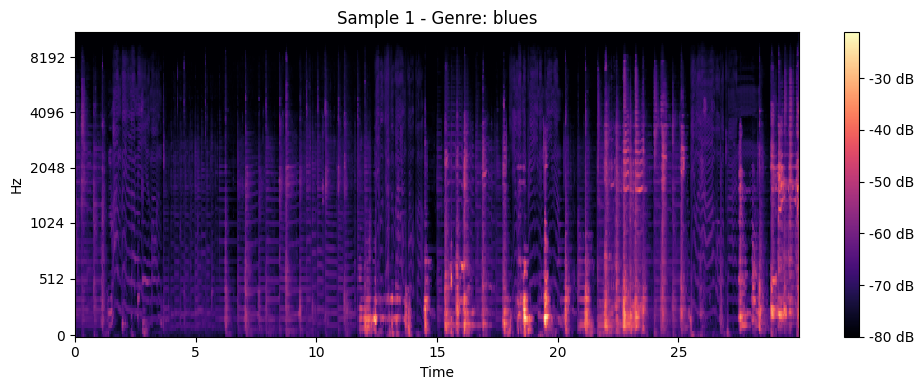

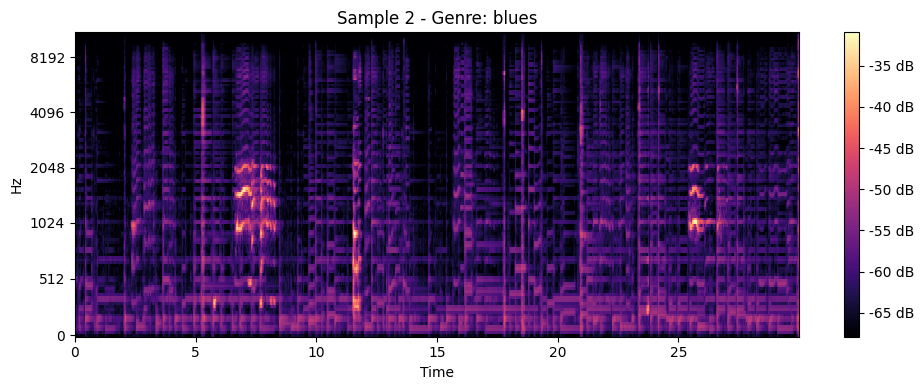

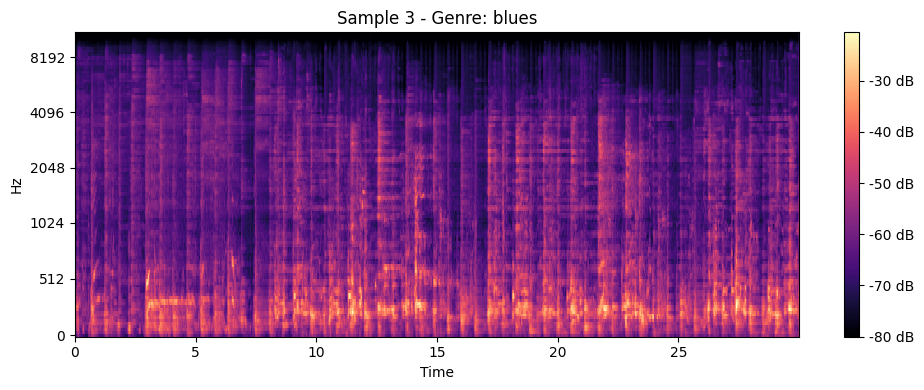

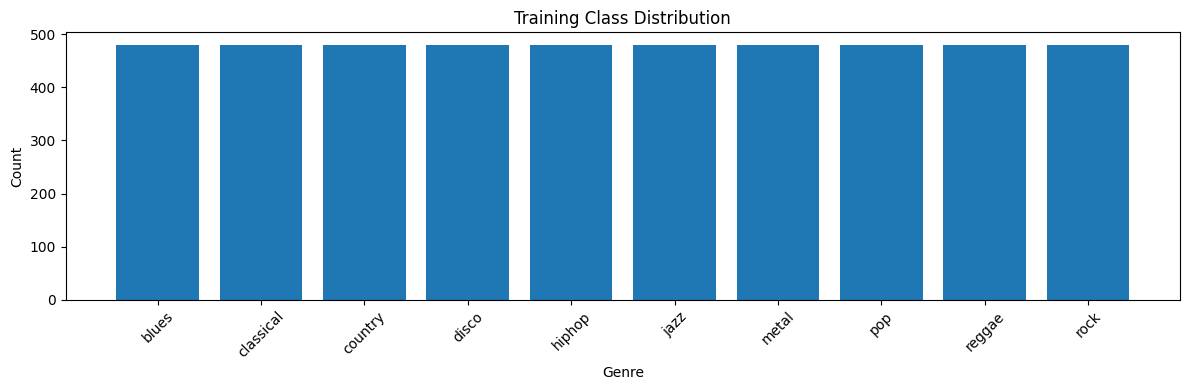

Train set size: 3840
Validation set size: 960


In [18]:
X, y = build_train_data(tr, aug=5)
print('Training samples:', len(X))
print('X shape:', X.shape)

# Visualize sample mel spectrograms
print('Sample mel spectrograms:')
for i in range(min(3, len(X))):
    visualize_mel_spectrogram(X[i], title=f'Sample {i+1} - Genre: {y[i]}')

# Plot class distribution
plot_class_distribution(y, title='Training Class Distribution')

# Prepare data for training
le = LabelEncoder()
le.fit(GENRES)
Xtr, Xv, ytr, yv = train_test_split(X, y, test_size=0.2, stratify=y, random_state=1234)

print('Train set size:', len(Xtr))
print('Validation set size:', len(Xv))

# Create data loaders
tl = DataLoader(DS(Xtr, ytr, le), batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
vl = DataLoader(DS(Xv, yv, le), batch_size=32, num_workers=2)

# Train all models

Starting model training...
TRAINING: CustomCNN


wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260314_185242-k6yv5w5d
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run CustomCNN
wandb: ⭐️ View project at https://wandb.ai/24f2001946-iitm/messy-mashup
wandb: 🚀 View run at https://wandb.ai/24f2001946-iitm/messy-mashup/runs/k6yv5w5d


Wandb run started: CustomCNN
Ep 1 / 30 : TrainLoss= 2.1502 ValLoss= 1.9866 F1= 0.2122 Acc= 0.2604
 Best F1: 0.2122
Ep 2 / 30 : TrainLoss= 1.872 ValLoss= 1.9904 F1= 0.2131 Acc= 0.2573
 Best F1: 0.2131
Ep 3 / 30 : TrainLoss= 1.7328 ValLoss= 1.8068 F1= 0.2725 Acc= 0.3042
 Best F1: 0.2725
Ep 4 / 30 : TrainLoss= 1.6533 ValLoss= 1.5581 F1= 0.3258 Acc= 0.3771
 Best F1: 0.3258
Ep 5 / 30 : TrainLoss= 1.6087 ValLoss= 1.9502 F1= 0.2689 Acc= 0.3177
Ep 6 / 30 : TrainLoss= 1.5424 ValLoss= 1.3284 F1= 0.4789 Acc= 0.5083
 Best F1: 0.4789
Ep 7 / 30 : TrainLoss= 1.4811 ValLoss= 1.4869 F1= 0.3829 Acc= 0.4302
Ep 8 / 30 : TrainLoss= 1.4157 ValLoss= 2.0034 F1= 0.3059 Acc= 0.3531
Ep 9 / 30 : TrainLoss= 1.3654 ValLoss= 3.1339 F1= 0.1831 Acc= 0.2354
Ep 10 / 30 : TrainLoss= 1.3117 ValLoss= 1.6743 F1= 0.3945 Acc= 0.4229
Ep 11 / 30 : TrainLoss= 1.2198 ValLoss= 1.2266 F1= 0.5484 Acc= 0.5521
 Best F1: 0.5484
Ep 12 / 30 : TrainLoss= 1.1697 ValLoss= 1.1787 F1= 0.5755 Acc= 0.5802
 Best F1: 0.5755
Ep 13 / 30 : TrainLoss

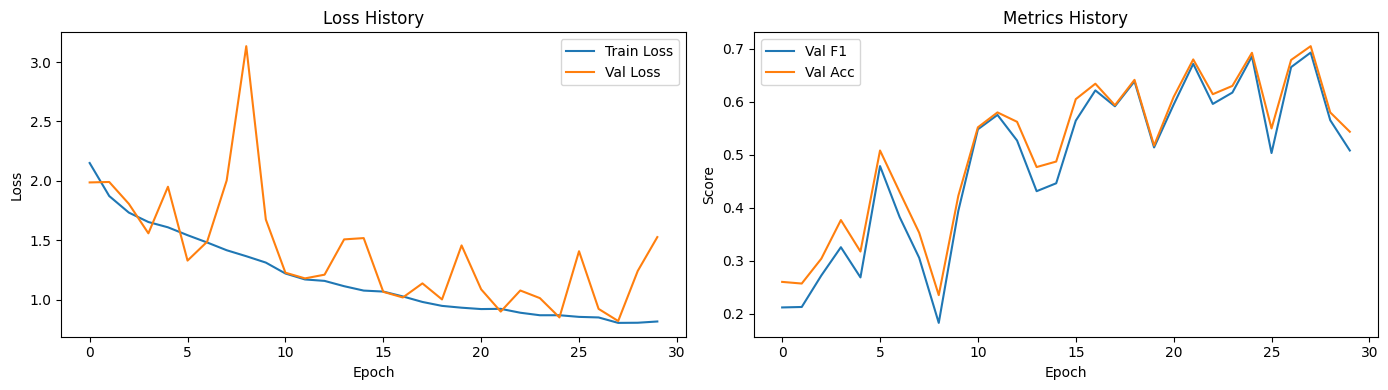

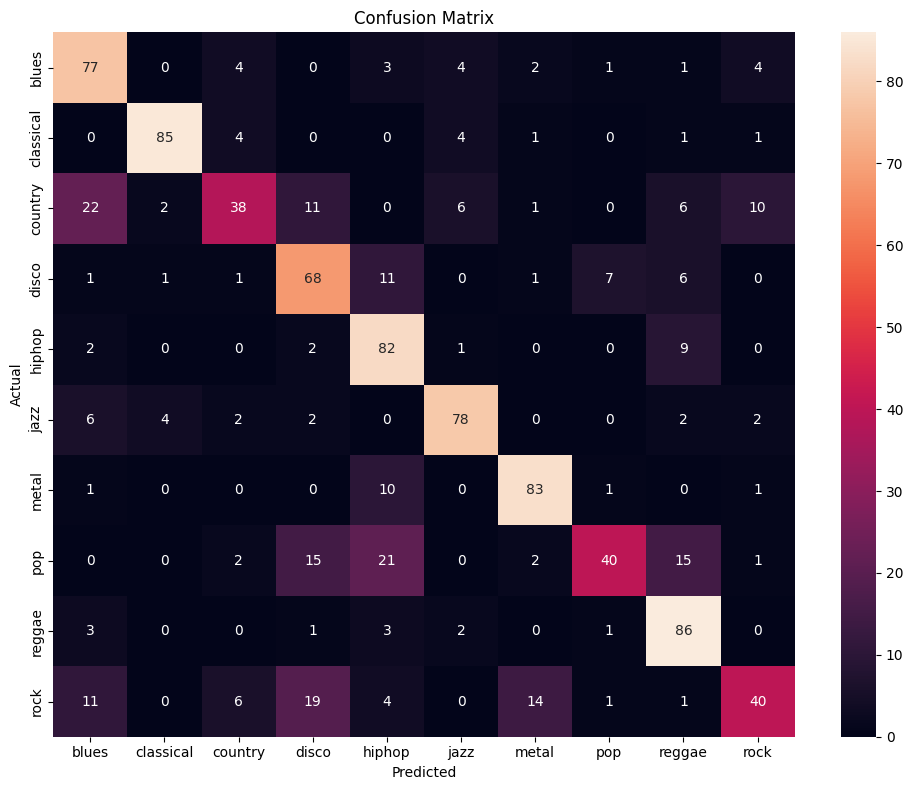

wandb: updating run metadata
wandb: uploading history steps 41-52, summary, console lines 42-42
wandb: 
wandb: Run history:
wandb:   best_epoch ▁▁▂▂▂▄▄▅▆▆▇█
wandb:      best_f1 ▁▁▂▃▅▆▆▇▇███
wandb:        epoch ▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
wandb:     f1_blues ▁
wandb: f1_classical ▁
wandb:   f1_country ▁
wandb:     f1_disco ▁
wandb:    f1_hiphop ▁
wandb:      f1_jazz ▁
wandb:     f1_metal ▁
wandb:          +10 ...
wandb: 
wandb: Run summary:
wandb:   best_epoch 28
wandb:      best_f1 0.69311
wandb:        epoch 30
wandb:     f1_blues 0.7032
wandb: f1_classical 0.90426
wandb:   f1_country 0.49673
wandb:     f1_disco 0.63551
wandb:    f1_hiphop 0.71304
wandb:      f1_jazz 0.81675
wandb:     f1_metal 0.83
wandb:          +10 ...
wandb: 
wandb: 🚀 View run CustomCNN at: https://wandb.ai/24f2001946-iitm/messy-mashup/runs/k6yv5w5d
wandb: ⭐️ View project at: https://wandb.ai/24f2001946-iitm/messy-mashup
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb

CustomCNN Best F1: 0.6931
Wandb run finished: CustomCNN
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 193MB/s]


TRAINING: ResNet18


wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260314_190222-na0i92ax
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run ResNet18
wandb: ⭐️ View project at https://wandb.ai/24f2001946-iitm/messy-mashup
wandb: 🚀 View run at https://wandb.ai/24f2001946-iitm/messy-mashup/runs/na0i92ax


Wandb run started: ResNet18
Ep 1 / 25 : TrainLoss= 1.6502 ValLoss= 1.4739 F1= 0.4594 Acc= 0.4708
 Best F1: 0.4594
Ep 2 / 25 : TrainLoss= 1.2226 ValLoss= 1.2541 F1= 0.5538 Acc= 0.5677
 Best F1: 0.5538
Ep 3 / 25 : TrainLoss= 0.9555 ValLoss= 1.1652 F1= 0.5838 Acc= 0.6031
 Best F1: 0.5838
Ep 4 / 25 : TrainLoss= 0.8334 ValLoss= 1.2744 F1= 0.5621 Acc= 0.5833
Ep 5 / 25 : TrainLoss= 0.6429 ValLoss= 1.2781 F1= 0.6113 Acc= 0.6219
 Best F1: 0.6113
Ep 6 / 25 : TrainLoss= 0.5432 ValLoss= 0.969 F1= 0.6687 Acc= 0.675
 Best F1: 0.6687
Ep 7 / 25 : TrainLoss= 0.4807 ValLoss= 1.5965 F1= 0.5739 Acc= 0.6021
Ep 8 / 25 : TrainLoss= 0.4104 ValLoss= 1.8415 F1= 0.5208 Acc= 0.5188
Ep 9 / 25 : TrainLoss= 0.3343 ValLoss= 3.9887 F1= 0.345 Acc= 0.3812
Ep 10 / 25 : TrainLoss= 0.2552 ValLoss= 0.929 F1= 0.726 Acc= 0.7281
 Best F1: 0.726
Ep 11 / 25 : TrainLoss= 0.2338 ValLoss= 0.7341 F1= 0.7835 Acc= 0.7802
 Best F1: 0.7835
Ep 12 / 25 : TrainLoss= 0.2153 ValLoss= 1.3331 F1= 0.6337 Acc= 0.649
Ep 13 / 25 : TrainLoss= 0.176

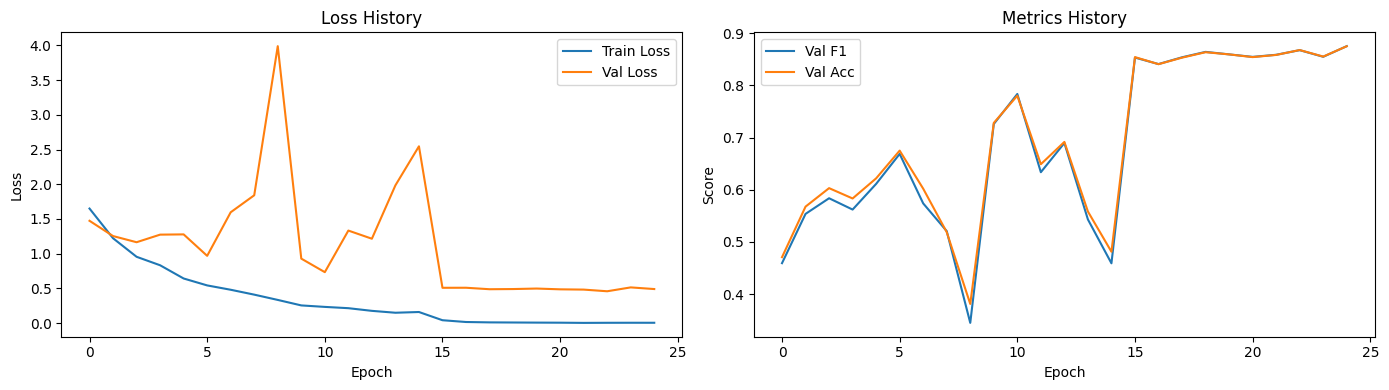

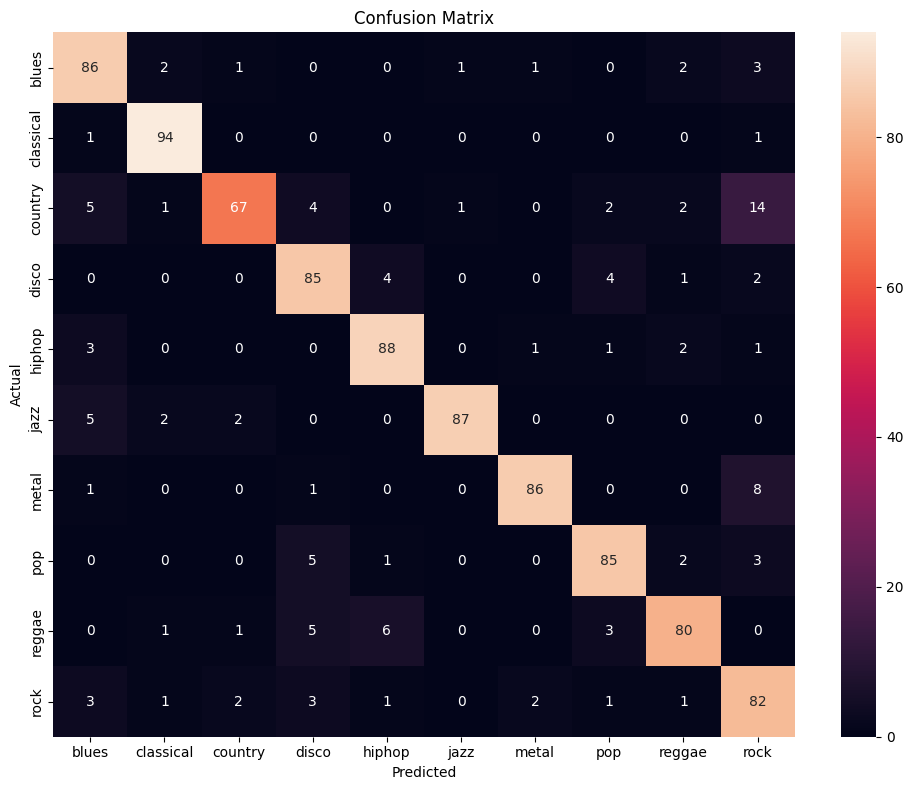

wandb: updating run metadata
wandb: uploading output.log; uploading wandb-summary.json; uploading config.yaml
wandb: 
wandb: Run history:
wandb:   best_epoch ▁▁▂▂▂▄▄▅▆▆▇█
wandb:      best_f1 ▁▃▃▄▅▅▆█████
wandb:        epoch ▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
wandb:     f1_blues ▁
wandb: f1_classical ▁
wandb:   f1_country ▁
wandb:     f1_disco ▁
wandb:    f1_hiphop ▁
wandb:      f1_jazz ▁
wandb:     f1_metal ▁
wandb:          +10 ...
wandb: 
wandb: Run summary:
wandb:   best_epoch 25
wandb:      best_f1 0.87513
wandb:        epoch 25
wandb:     f1_blues 0.86
wandb: f1_classical 0.95431
wandb:   f1_country 0.7929
wandb:     f1_disco 0.85427
wandb:    f1_hiphop 0.89796
wandb:      f1_jazz 0.94054
wandb:     f1_metal 0.92473
wandb:          +10 ...
wandb: 
wandb: 🚀 View run ResNet18 at: https://wandb.ai/24f2001946-iitm/messy-mashup/runs/na0i92ax
wandb: ⭐️ View project at: https://wandb.ai/24f2001946-iitm/messy-mashup
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(

ResNet18 Best F1: 0.8751
Wandb run finished: ResNet18
TRAINING: DepthwiseCNN


wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260314_191043-j9iloog4
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run DepthwiseCNN
wandb: ⭐️ View project at https://wandb.ai/24f2001946-iitm/messy-mashup
wandb: 🚀 View run at https://wandb.ai/24f2001946-iitm/messy-mashup/runs/j9iloog4


Wandb run started: DepthwiseCNN
Ep 1 / 25 : TrainLoss= 1.8308 ValLoss= 1.6238 F1= 0.3404 Acc= 0.3969
 Best F1: 0.3404
Ep 2 / 25 : TrainLoss= 1.357 ValLoss= 1.2154 F1= 0.5267 Acc= 0.551
 Best F1: 0.5267
Ep 3 / 25 : TrainLoss= 1.1096 ValLoss= 1.2064 F1= 0.5596 Acc= 0.5667
 Best F1: 0.5596
Ep 4 / 25 : TrainLoss= 0.9309 ValLoss= 1.0411 F1= 0.6166 Acc= 0.6323
 Best F1: 0.6166
Ep 5 / 25 : TrainLoss= 0.7809 ValLoss= 1.3456 F1= 0.5458 Acc= 0.5552
Ep 6 / 25 : TrainLoss= 0.6889 ValLoss= 1.0719 F1= 0.6347 Acc= 0.6323
 Best F1: 0.6347
Ep 7 / 25 : TrainLoss= 0.578 ValLoss= 0.8961 F1= 0.6931 Acc= 0.6969
 Best F1: 0.6931
Ep 8 / 25 : TrainLoss= 0.5055 ValLoss= 0.8992 F1= 0.6884 Acc= 0.6979
Ep 9 / 25 : TrainLoss= 0.4275 ValLoss= 0.8485 F1= 0.7164 Acc= 0.7135
 Best F1: 0.7164
Ep 10 / 25 : TrainLoss= 0.3459 ValLoss= 0.673 F1= 0.7706 Acc= 0.7708
 Best F1: 0.7706
Ep 11 / 25 : TrainLoss= 0.3397 ValLoss= 0.9354 F1= 0.6987 Acc= 0.7125
Ep 12 / 25 : TrainLoss= 0.2709 ValLoss= 0.6698 F1= 0.777 Acc= 0.775
 Best F

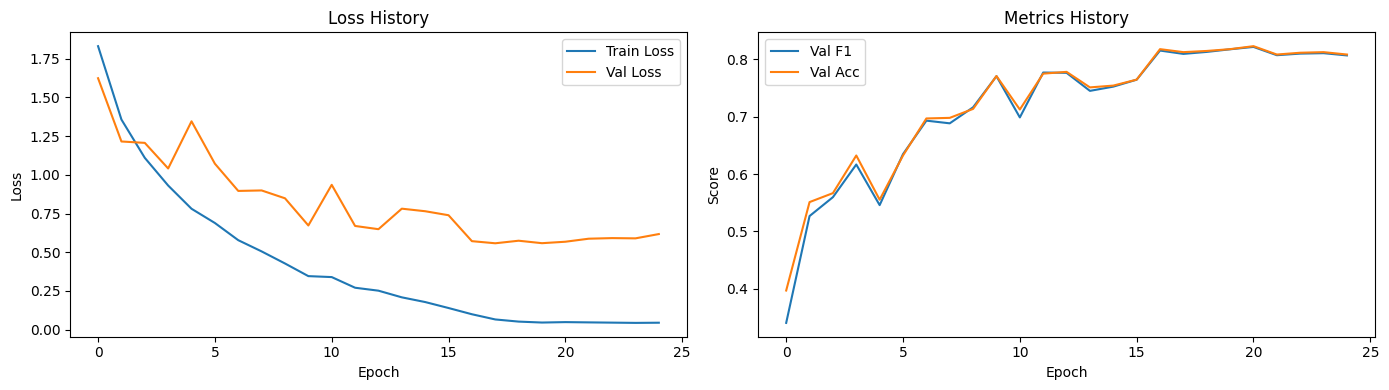

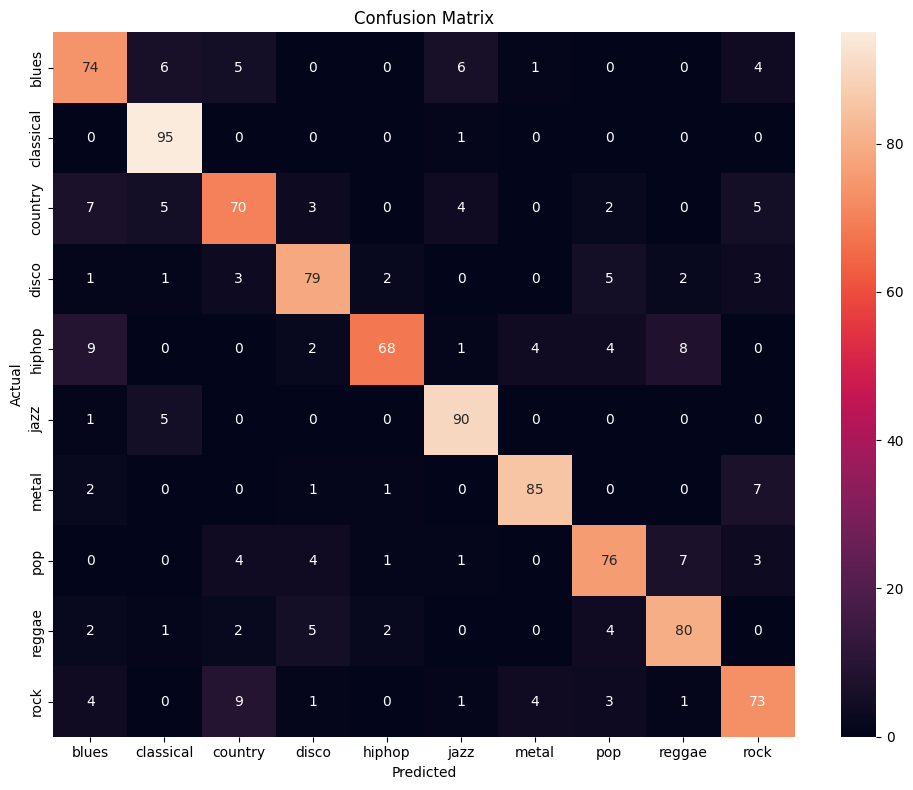

wandb: updating run metadata
wandb: uploading output.log; uploading wandb-summary.json; uploading config.yaml
wandb: 
wandb: Run history:
wandb:   best_epoch ▁▁▂▂▃▃▄▄▅▇██
wandb:      best_f1 ▁▄▄▅▅▆▆▇▇███
wandb:        epoch ▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
wandb:     f1_blues ▁
wandb: f1_classical ▁
wandb:   f1_country ▁
wandb:     f1_disco ▁
wandb:    f1_hiphop ▁
wandb:      f1_jazz ▁
wandb:     f1_metal ▁
wandb:          +10 ...
wandb: 
wandb: Run summary:
wandb:   best_epoch 21
wandb:      best_f1 0.8216
wandb:        epoch 25
wandb:     f1_blues 0.7551
wandb: f1_classical 0.90909
wandb:   f1_country 0.74074
wandb:     f1_disco 0.82723
wandb:    f1_hiphop 0.8
wandb:      f1_jazz 0.9
wandb:     f1_metal 0.89474
wandb:          +10 ...
wandb: 
wandb: 🚀 View run DepthwiseCNN at: https://wandb.ai/24f2001946-iitm/messy-mashup/runs/j9iloog4
wandb: ⭐️ View project at: https://wandb.ai/24f2001946-iitm/messy-mashup
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)

DepthwiseCNN Best F1: 0.8216
Wandb run finished: DepthwiseCNN


In [19]:
print('Starting model training...')

model1 = CustomCNN().to(DEVICE)
model1, f1_1, hist1 = train_model(model1, "CustomCNN", tl, vl, le, ep=30)

model2 = PretrainedResNet().to(DEVICE)
model2, f1_2, hist2 = train_model(model2, "ResNet18", tl, vl, le, ep=25)

model3 = DepthwiseCNN().to(DEVICE)
model3, f1_3, hist3 = train_model(model3, "DepthwiseCNN", tl, vl, le, ep=25)

# Compare model performances

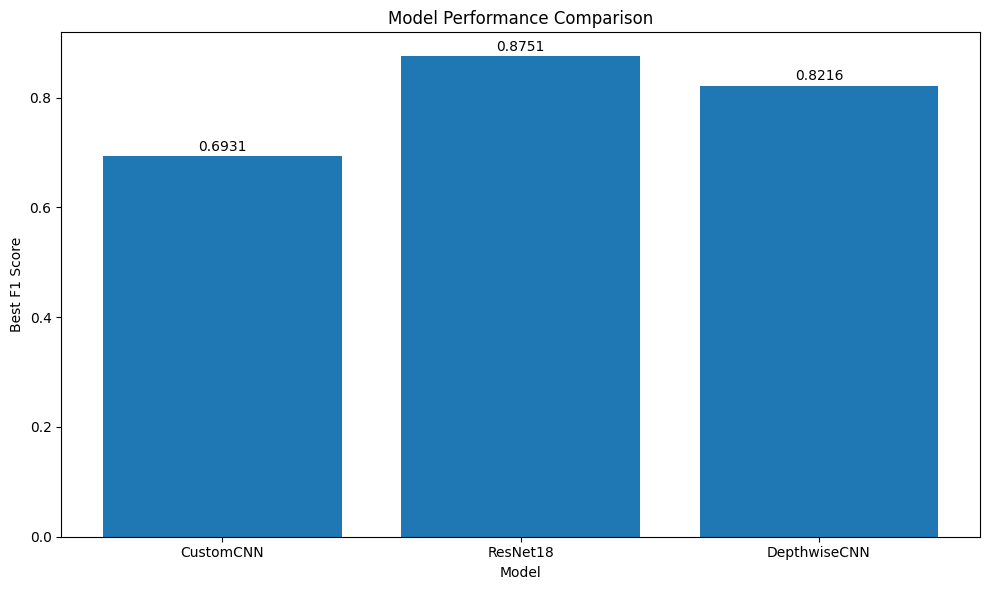

Model Performance:
CustomCNN F1: 0.6931
ResNet18 F1: 0.8751
DepthwiseCNN F1: 0.8216


In [20]:
models_performance = {
    'CustomCNN': f1_1,
    'ResNet18': f1_2,
    'DepthwiseCNN': f1_3
}

plt.figure(figsize=(10, 6))
plt.bar(models_performance.keys(), models_performance.values())
plt.title('Model Performance Comparison')
plt.xlabel('Model')
plt.ylabel('Best F1 Score')
for i, (model, score) in enumerate(models_performance.items()):
    plt.text(i, score + 0.01, f'{score:.4f}', ha='center')
plt.tight_layout()
plt.show()

print('Model Performance:')
for model, score in models_performance.items():
    print(model, 'F1:', round(score, 4))

# Ensemble predictions

ENSEMBLE PREDICTIONS
Predicting with CustomCNN ...


  0%|          | 0/3020 [00:00<?, ?it/s]

Predicting with ResNet18 ...


  0%|          | 0/3020 [00:00<?, ?it/s]

Predicting with DepthwiseCNN ...


  0%|          | 0/3020 [00:00<?, ?it/s]

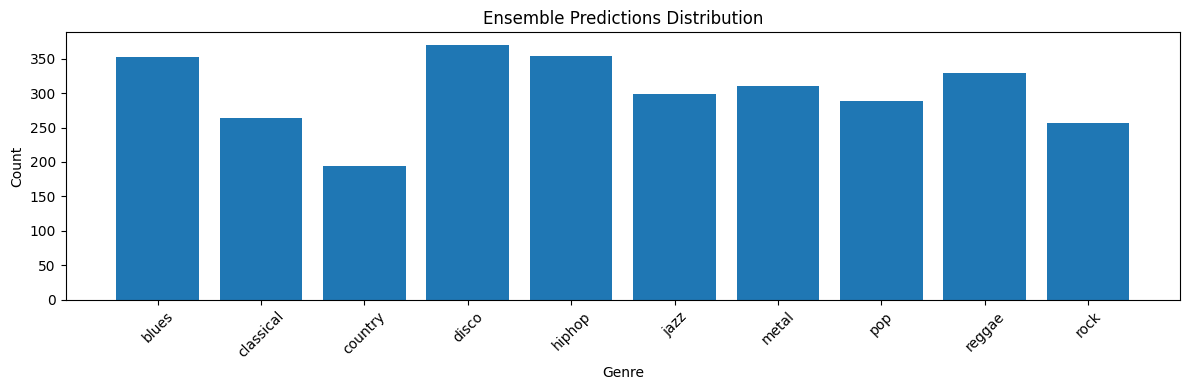

In [21]:
print('ENSEMBLE PREDICTIONS')
preds1 = predict(model1, le, "CustomCNN")
preds2 = predict(model2, le, "ResNet18")
preds3 = predict(model3, le, "DepthwiseCNN")

test = pd.read_csv(os.path.join(BASE, "test.csv"))
ensemble_preds = []

for p1, p2, p3 in zip(preds1, preds2, preds3):
    votes = {}
    for pred, f1 in [(p1, f1_1), (p2, f1_2), (p3, f1_3)]:
        votes[pred] = votes.get(pred, 0) + f1
    ensemble_preds.append(max(votes, key=votes.get))

# Visualize ensemble predictions distribution
plt.figure(figsize=(12, 4))
unique, counts = np.unique(ensemble_preds, return_counts=True)
plt.bar(unique, counts)
plt.title('Ensemble Predictions Distribution')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Save submission files

In [22]:
pd.DataFrame({'id': test['id'], 'genre': preds1}).to_csv('submission_cnn.csv', index=False)
pd.DataFrame({'id': test['id'], 'genre': preds2}).to_csv('submission_resnet.csv', index=False)
pd.DataFrame({'id': test['id'], 'genre': preds3}).to_csv('submission_depthwise.csv', index=False)
pd.DataFrame({'id': test['id'], 'genre': ensemble_preds}).to_csv('submission.csv', index=False)

print('Submission files saved:')
print('- submission_cnn.csv')
print('- submission_resnet.csv')
print('- submission_depthwise.csv')
print('- submission.csv')

Submission files saved:
- submission_cnn.csv
- submission_resnet.csv
- submission_depthwise.csv
- submission.csv


# Final summary

In [23]:
print('PROJECT COMPLETE')
print('CustomCNN F1:', round(f1_1, 4))
print('ResNet18 F1:', round(f1_2, 4))
print('DepthwiseCNN F1:', round(f1_3, 4))
print('Ensemble created with weighted voting')
print('Wandb dashboard: https://wandb.ai/24f2001946-iitm/messy-mashup')

PROJECT COMPLETE
CustomCNN F1: 0.6931
ResNet18 F1: 0.8751
DepthwiseCNN F1: 0.8216
Ensemble created with weighted voting
Wandb dashboard: https://wandb.ai/24f2001946-iitm/messy-mashup
